In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv("credit_card_fraud_10k.csv")

In [32]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [33]:
(df["amount"] == 0).any()

np.True_

In [26]:
# Returns an array/list of column names containing 0
df.columns[(df == 0).any()].tolist()


['amount',
 'transaction_hour',
 'foreign_transaction',
 'location_mismatch',
 'velocity_last_24h',
 'is_fraud']

In [34]:
(df["amount"] < 0).any()

np.False_

In [28]:
#Lets start handle outliers



In [61]:
from sklearn.preprocessing import PowerTransformer

In [62]:

yj = PowerTransformer(method='yeo-johnson')

df["amount"] = yj.fit_transform(df[['amount']])



In [63]:
df["velocity_last_24h"] = yj.fit_transform(df[["velocity_last_24h"]])

In [58]:
df["velocity_last_24h"].skew()

np.float64(-0.03512050987890932)

<Axes: ylabel='Frequency'>

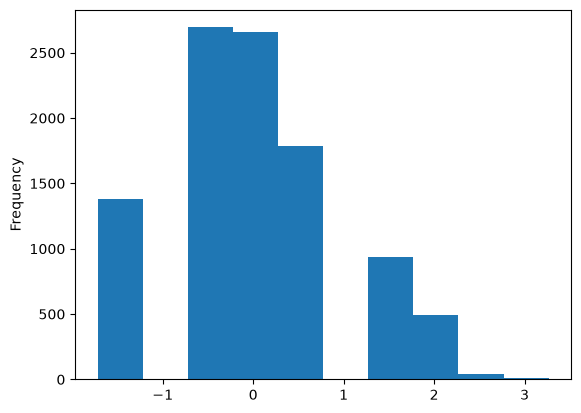

In [59]:
df["velocity_last_24h"].plot(kind='hist')

In [64]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

# Filter using the boxplot's exact whisker limits
df_clean = df[(df['amount'] >= Q1 - 1.5 * IQR) & (df['amount'] <= Q3 + 1.5 * IQR)]


In [52]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [65]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[['merchant_category']])

In [65]:
df.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,-0.297073,22,0,0,66,0.773288,40,0,1.0,0.0,0.0,0.0
1,2,1.653014,3,1,0,87,-0.629512,64,0,0.0,0.0,0.0,1.0
2,3,0.676127,17,0,0,49,-0.629512,61,0,0.0,0.0,1.0,0.0
3,4,0.302215,4,0,1,72,0.773288,34,0,0.0,0.0,1.0,0.0
4,5,-1.040724,15,0,0,79,-1.718677,44,0,0.0,1.0,0.0,0.0


In [66]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['merchant_category']),
    index=df.index
)

df = pd.concat(
    [df.drop(columns=['merchant_category']), encoded_df],
    axis=1
)

In [40]:
df.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,-0.297073,22,0,0,66,3,40,0,1.0,0.0,0.0,0.0
1,2,1.653014,3,1,0,87,1,64,0,0.0,0.0,0.0,1.0
2,3,0.676127,17,0,0,49,1,61,0,0.0,0.0,1.0,0.0
3,4,0.302215,4,0,1,72,3,34,0,0.0,0.0,1.0,0.0
4,5,-1.040724,15,0,0,79,0,44,0,0.0,1.0,0.0,0.0


In [67]:
X = df.drop(columns=['is_fraud'])

In [73]:
X.shape

(10000, 11)

In [46]:
X.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,-0.297073,22,0,0,66,3,40,1.0,0.0,0.0,0.0
1,2,1.653014,3,1,0,87,1,64,0.0,0.0,0.0,1.0
2,3,0.676127,17,0,0,49,1,61,0.0,0.0,1.0,0.0
3,4,0.302215,4,0,1,72,3,34,0.0,0.0,1.0,0.0
4,5,-1.040724,15,0,0,79,0,44,0.0,1.0,0.0,0.0


In [68]:
y = df["is_fraud"]

In [43]:
y.shape

(10000,)

In [44]:
df.shape

(10000, 13)

In [45]:
df.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,-0.297073,22,0,0,66,3,40,0,1.0,0.0,0.0,0.0
1,2,1.653014,3,1,0,87,1,64,0,0.0,0.0,0.0,1.0
2,3,0.676127,17,0,0,49,1,61,0,0.0,0.0,1.0,0.0
3,4,0.302215,4,0,1,72,3,34,0,0.0,0.0,1.0,0.0
4,5,-1.040724,15,0,0,79,0,44,0,0.0,1.0,0.0,0.0


In [69]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select ONLY numeric features (VIF only works on numbers)
# Assumes X_resampled contains your encoded, numeric features
X_vif = X.copy()

# 2. Add a constant column (Crucial for correct VIF calculations in statsmodels)
X_vif['intercept'] = 1

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 4. Drop the intercept row from final view and sort
vif_data = vif_data[vif_data['feature'] != 'intercept'].sort_values(by="VIF", ascending=False)
print(vif_data)


                          feature       VIF
9          merchant_category_Food  1.599418
11       merchant_category_Travel  1.580090
10      merchant_category_Grocery  1.569846
8   merchant_category_Electronics  1.567000
0                  transaction_id  1.001488
5              device_trust_score  1.001416
2                transaction_hour  1.000947
6               velocity_last_24h  1.000818
7                  cardholder_age  1.000671
4               location_mismatch  1.000577
3             foreign_transaction  1.000553
1                          amount  1.000435


In [70]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# 1. Separate your continuous numerical columns from your binary/dummy columns
num_cols = ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

# 2. Set up the ColumnTransformer
# 'passthrough' ensures that all columns NOT listed in num_cols are left completely alone
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough' 
)

# 3. Fit and transform your resampled features
X_scaled_array = preprocessor.fit_transform(X)

# 4. (Optional) Convert it back into a clean Pandas DataFrame with original column names
# Get the order of columns after transformation
all_columns = num_cols + [col for col in X.columns if col not in num_cols]
X_scaled = pd.DataFrame(X_scaled_array, columns=all_columns)

print(X_scaled.head())


     amount  transaction_hour  device_trust_score  velocity_last_24h  \
0 -0.297073          1.503345            0.195528           0.773288   
1  1.653014         -1.241383            1.172909          -0.629512   
2  0.676127          0.781048           -0.595686          -0.629512   
3  0.302215         -1.096923            0.474779           0.773288   
4 -1.040724          0.492130            0.800573          -1.718677   

   cardholder_age  transaction_id  foreign_transaction  location_mismatch  \
0       -0.231580             1.0                  0.0                0.0   
1        1.370727             2.0                  1.0                0.0   
2        1.170439             3.0                  0.0                0.0   
3       -0.632157             4.0                  0.0                1.0   
4        0.035471             5.0                  0.0                0.0   

   merchant_category_Electronics  merchant_category_Food  \
0                            1.0            

In [71]:
X = X_scaled

In [50]:
X.head()

,amount,transaction_hour,device_trust_score,velocity_last_24h,cardholder_age,transaction_id,foreign_transaction,location_mismatch,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,-0.297073,1.503345,0.195528,0.691873,-0.231580,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.653014,-1.241383,1.172909,-0.704299,1.370727,2.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.676127,0.781048,-0.595686,-0.704299,1.170439,3.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.302215,-1.096923,0.474779,0.691873,-0.632157,4.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.040724,0.492130,0.800573,-1.402386,0.035471,5.0,0.0,0.0,0.0,1.0,0.0,0.0


In [72]:
y.shape

(10000,)

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [74]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)

X_train_resampled, y_train_resampled = smoteenn.fit_resample(
    X_train, y_train
)

In [75]:
print(y_train_resampled.value_counts())
print(y_valid.value_counts())

is_fraud
1    6011
0    3449
Name: count, dtype: int64
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=159,
    max_depth=11,
    min_samples_split=16,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",159
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",11
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",16
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [77]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix
)

y_pred = rf.predict(X_valid)
y_proba = rf.predict_proba(X_valid)[:, 1]

print("Average Precision:", average_precision_score(y_valid, y_proba))
print(confusion_matrix(y_valid, y_pred))
print(classification_report(y_valid, y_pred))

Average Precision: 0.7808661338043256
[[1929   41]
 [   6   24]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.37      0.80      0.51        30

    accuracy                           0.98      2000
   macro avg       0.68      0.89      0.75      2000
weighted avg       0.99      0.98      0.98      2000



In [79]:
from sklearn.metrics import classification_report, confusion_matrix

# Try a lower threshold
threshold = 0.35

y_pred_new = (y_proba >= threshold).astype(int)

print(confusion_matrix(y_valid, y_pred_new))
print(classification_report(y_valid, y_pred_new))

[[1887   83]
 [   0   30]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.27      1.00      0.42        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000



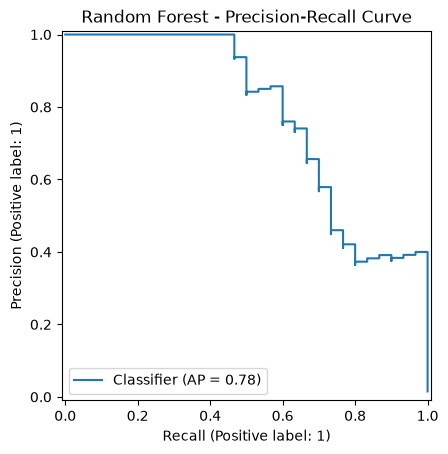

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_valid, y_proba)
plt.title("Random Forest - Precision-Recall Curve")
plt.show()

In [ ]:

# import optuna
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import average_precision_score
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from catboost import CatBoostClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier



In [ ]:

# ratio = (y_train == 0).sum() / (y_train == 1).sum()

# def objective(trial, algo):
#     if algo == "Decision Tree":
#         model = DecisionTreeClassifier(
#             max_depth=trial.suggest_int("max_depth", 3, 20),
#             min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
#             min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
#             class_weight="balanced",
#             random_state=42
#         )

#     elif algo == "Random Forest":
#         model = RandomForestClassifier(
#             n_estimators=trial.suggest_int("n_estimators", 100, 300),
#             max_depth=trial.suggest_int("max_depth", 5, 20),
#             min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
#             min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
#             class_weight="balanced",
#             random_state=42, n_jobs=-1
#         )

#     elif algo == "CatBoost":
#         model = CatBoostClassifier(
#             iterations=trial.suggest_int("iterations", 200, 600),
#             depth=trial.suggest_int("depth", 4, 10),
#             learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#             auto_class_weights="Balanced",
#             verbose=0, random_seed=42
#         )

#     elif algo == "XGBoost":
#         model = XGBClassifier(
#             n_estimators=trial.suggest_int("n_estimators", 100, 400),
#             max_depth=trial.suggest_int("max_depth", 3, 10),
#             learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#             scale_pos_weight=ratio,
#             eval_metric="aucpr", random_state=42, n_jobs=-1
#         )

#     elif algo == "LightGBM":
#         model = LGBMClassifier(
#             n_estimators=trial.suggest_int("n_estimators", 100, 400),
#             max_depth=trial.suggest_int("max_depth", 3, 12),
#             num_leaves=trial.suggest_int("num_leaves", 15, 63),
#             learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#             scale_pos_weight=ratio,
#             verbosity=-1, random_state=42, n_jobs=-1
#         )

#     model.fit(X_train, y_train)
#     pred = model.predict_proba(X_valid)[:, 1]

#     return average_precision_score(y_valid, pred)


# algorithms = [
#     "Decision Tree", "Random Forest",
#     "CatBoost", "XGBoost", "LightGBM"
# ]

# for algo in algorithms:
#     study = optuna.create_study(direction="maximize")
#     study.optimize(lambda trial: objective(trial, algo), n_trials=10)

#     print(f"\n{algo}")
#     print("Best score:", study.best_value)
#     print("Best parameters:", study.best_params)

[I 2026-10-09 09:23:32,972] A new study created in memory with name: no-name-8db81d95-cdc2-4538-8480-268ddb4a4532
[I 2026-10-09 09:23:33,052] Trial 0 finished with value: 0.8822958170861397 and parameters: {'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8822958170861397.
[I 2026-10-09 09:23:33,108] Trial 1 finished with value: 0.9349444444444444 and parameters: {'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.9349444444444444.
[I 2026-10-09 09:23:33,160] Trial 2 finished with value: 0.8681652885199858 and parameters: {'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.9349444444444444.
[I 2026-10-09 09:23:33,209] Trial 3 finished with value: 0.8751171637004971 and parameters: {'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.9349444444444444.
[I 2026-10-09 09:23:33,260] Trial 4 finished with value: 0.


Decision Tree
Best score: 0.9671666666666666
Best parameters: {'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 4}


[I 2026-10-09 09:23:35,911] Trial 0 finished with value: 0.9999999999999999 and parameters: {'n_estimators': 217, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.9999999999999999.
[I 2026-10-09 09:23:37,071] Trial 1 finished with value: 0.9880804953560371 and parameters: {'n_estimators': 113, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.9999999999999999.
[I 2026-10-09 09:23:38,169] Trial 2 finished with value: 0.9969696969696968 and parameters: {'n_estimators': 179, 'max_depth': 17, 'min_samples_split': 14, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.9999999999999999.
[I 2026-10-09 09:23:39,146] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 159, 'max_depth': 11, 'min_samples_split': 16, 'min_samples_leaf': 8}. Best is trial 3 with value: 1.0.
[I 2026-10-09 09:23:40,331] Trial 4 finished with value: 1.0 and parameters: {'n_estimators': 179, 'max_depth': 18, 'min


Random Forest
Best score: 1.0
Best parameters: {'n_estimators': 159, 'max_depth': 11, 'min_samples_split': 16, 'min_samples_leaf': 8}


[I 2026-10-09 09:23:57,664] Trial 0 finished with value: 0.9999999999999999 and parameters: {'iterations': 577, 'depth': 9, 'learning_rate': 0.05885071012858625}. Best is trial 0 with value: 0.9999999999999999.
[I 2026-10-09 09:24:02,431] Trial 1 finished with value: 0.9999999999999999 and parameters: {'iterations': 594, 'depth': 5, 'learning_rate': 0.2422942499576485}. Best is trial 0 with value: 0.9999999999999999.
[I 2026-10-09 09:24:07,415] Trial 2 finished with value: 0.9999999999999999 and parameters: {'iterations': 255, 'depth': 9, 'learning_rate': 0.09632719609234369}. Best is trial 0 with value: 0.9999999999999999.
[I 2026-10-09 09:24:12,169] Trial 3 finished with value: 0.9999999999999999 and parameters: {'iterations': 580, 'depth': 4, 'learning_rate': 0.183073355707842}. Best is trial 0 with value: 0.9999999999999999.
[I 2026-10-09 09:24:22,039] Trial 4 finished with value: 0.9999999999999999 and parameters: {'iterations': 426, 'depth': 9, 'learning_rate': 0.0825685572927711


CatBoost
Best score: 1.0
Best parameters: {'iterations': 378, 'depth': 4, 'learning_rate': 0.09619594358848131}


[I 2026-10-09 09:24:40,358] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 122, 'max_depth': 6, 'learning_rate': 0.06701910553082904}. Best is trial 0 with value: 1.0.
[I 2026-10-09 09:24:42,747] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 390, 'max_depth': 8, 'learning_rate': 0.10089128536913744}. Best is trial 0 with value: 1.0.
[I 2026-10-09 09:24:45,752] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 208, 'max_depth': 5, 'learning_rate': 0.01428637068804359}. Best is trial 0 with value: 1.0.
[I 2026-10-09 09:24:52,001] Trial 3 finished with value: 0.9999999999999999 and parameters: {'n_estimators': 321, 'max_depth': 10, 'learning_rate': 0.022741349053126775}. Best is trial 0 with value: 1.0.
[I 2026-10-09 09:24:54,564] Trial 4 finished with value: 1.0 and parameters: {'n_estimators': 351, 'max_depth': 7, 'learning_rate': 0.0548753495468234}. Best is trial 0 with value: 1.0.
[I 2026-10-09 09:24:55,948] Trial 5 finished with


XGBoost
Best score: 1.0
Best parameters: {'n_estimators': 122, 'max_depth': 6, 'learning_rate': 0.06701910553082904}


[I 2026-10-09 09:25:05,418] Trial 0 finished with value: 0.04861977863438606 and parameters: {'n_estimators': 307, 'max_depth': 7, 'num_leaves': 25, 'learning_rate': 0.21472719542231164}. Best is trial 0 with value: 0.04861977863438606.
[I 2026-10-09 09:25:05,787] Trial 1 finished with value: 0.9999999999999999 and parameters: {'n_estimators': 304, 'max_depth': 3, 'num_leaves': 16, 'learning_rate': 0.05066987698153594}. Best is trial 1 with value: 0.9999999999999999.
[I 2026-10-09 09:25:06,072] Trial 2 finished with value: 0.996969696969697 and parameters: {'n_estimators': 125, 'max_depth': 10, 'num_leaves': 15, 'learning_rate': 0.0116018213599273}. Best is trial 1 with value: 0.9999999999999999.
[I 2026-10-09 09:25:06,418] Trial 3 finished with value: 0.9979166666666668 and parameters: {'n_estimators': 129, 'max_depth': 10, 'num_leaves': 18, 'learning_rate': 0.04765181509511844}. Best is trial 1 with value: 0.9999999999999999.
[I 2026-10-09 09:25:06,945] Trial 4 finished with value: 0


LightGBM
Best score: 1.0
Best parameters: {'n_estimators': 400, 'max_depth': 10, 'num_leaves': 16, 'learning_rate': 0.1073519221644233}
